In [24]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se

import mqt.qecc

import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [25]:
g = PrismGraph("red junction")

prisms = [
    (Position3DHex(0,0,1), "NN", "middle"),
    (Position3DHex(0,0,2), "NZ", "top"),
    (Position3DHex(0,0,0), "ZN", "bottom"),
    (Position3DHex(1,1,1), "XX", "left"),
    (Position3DHex(-1,1,1), "XX", "right"),
    (Position3DHex(1,-1,1), "XX", "down"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)


In [26]:
#middle bottom
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

#middle top
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#middle left
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[3][0], pipe_kind)

#middle right
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[4][0], pipe_kind)

#middle down
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[5][0], pipe_kind)

In [27]:
g.view_as_html()

In [28]:
z=0
d=7
stabs_x, stabs_z, _, _, _ = g.stabilizers_timeslice(z,d)

In [29]:
z=1
d=7
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

In [18]:
z=2
d=7
stabs_x, stabs_z, _, _, _ = g.stabilizers_timeslice(z,d)

/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/temp-laura/temp_utils.py:121: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


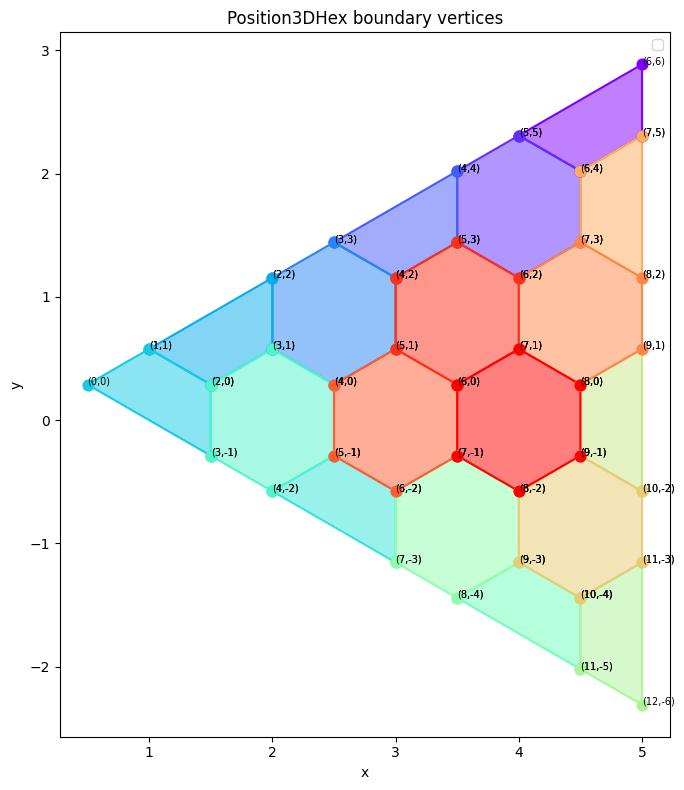

In [19]:
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_x)

In [20]:
stabs_z[0]

[Position3DHex(x=6, y=6, z=2),
 Position3DHex(x=5, y=5, z=2),
 Position3DHex(x=6, y=4, z=2),
 Position3DHex(x=7, y=5, z=2)]

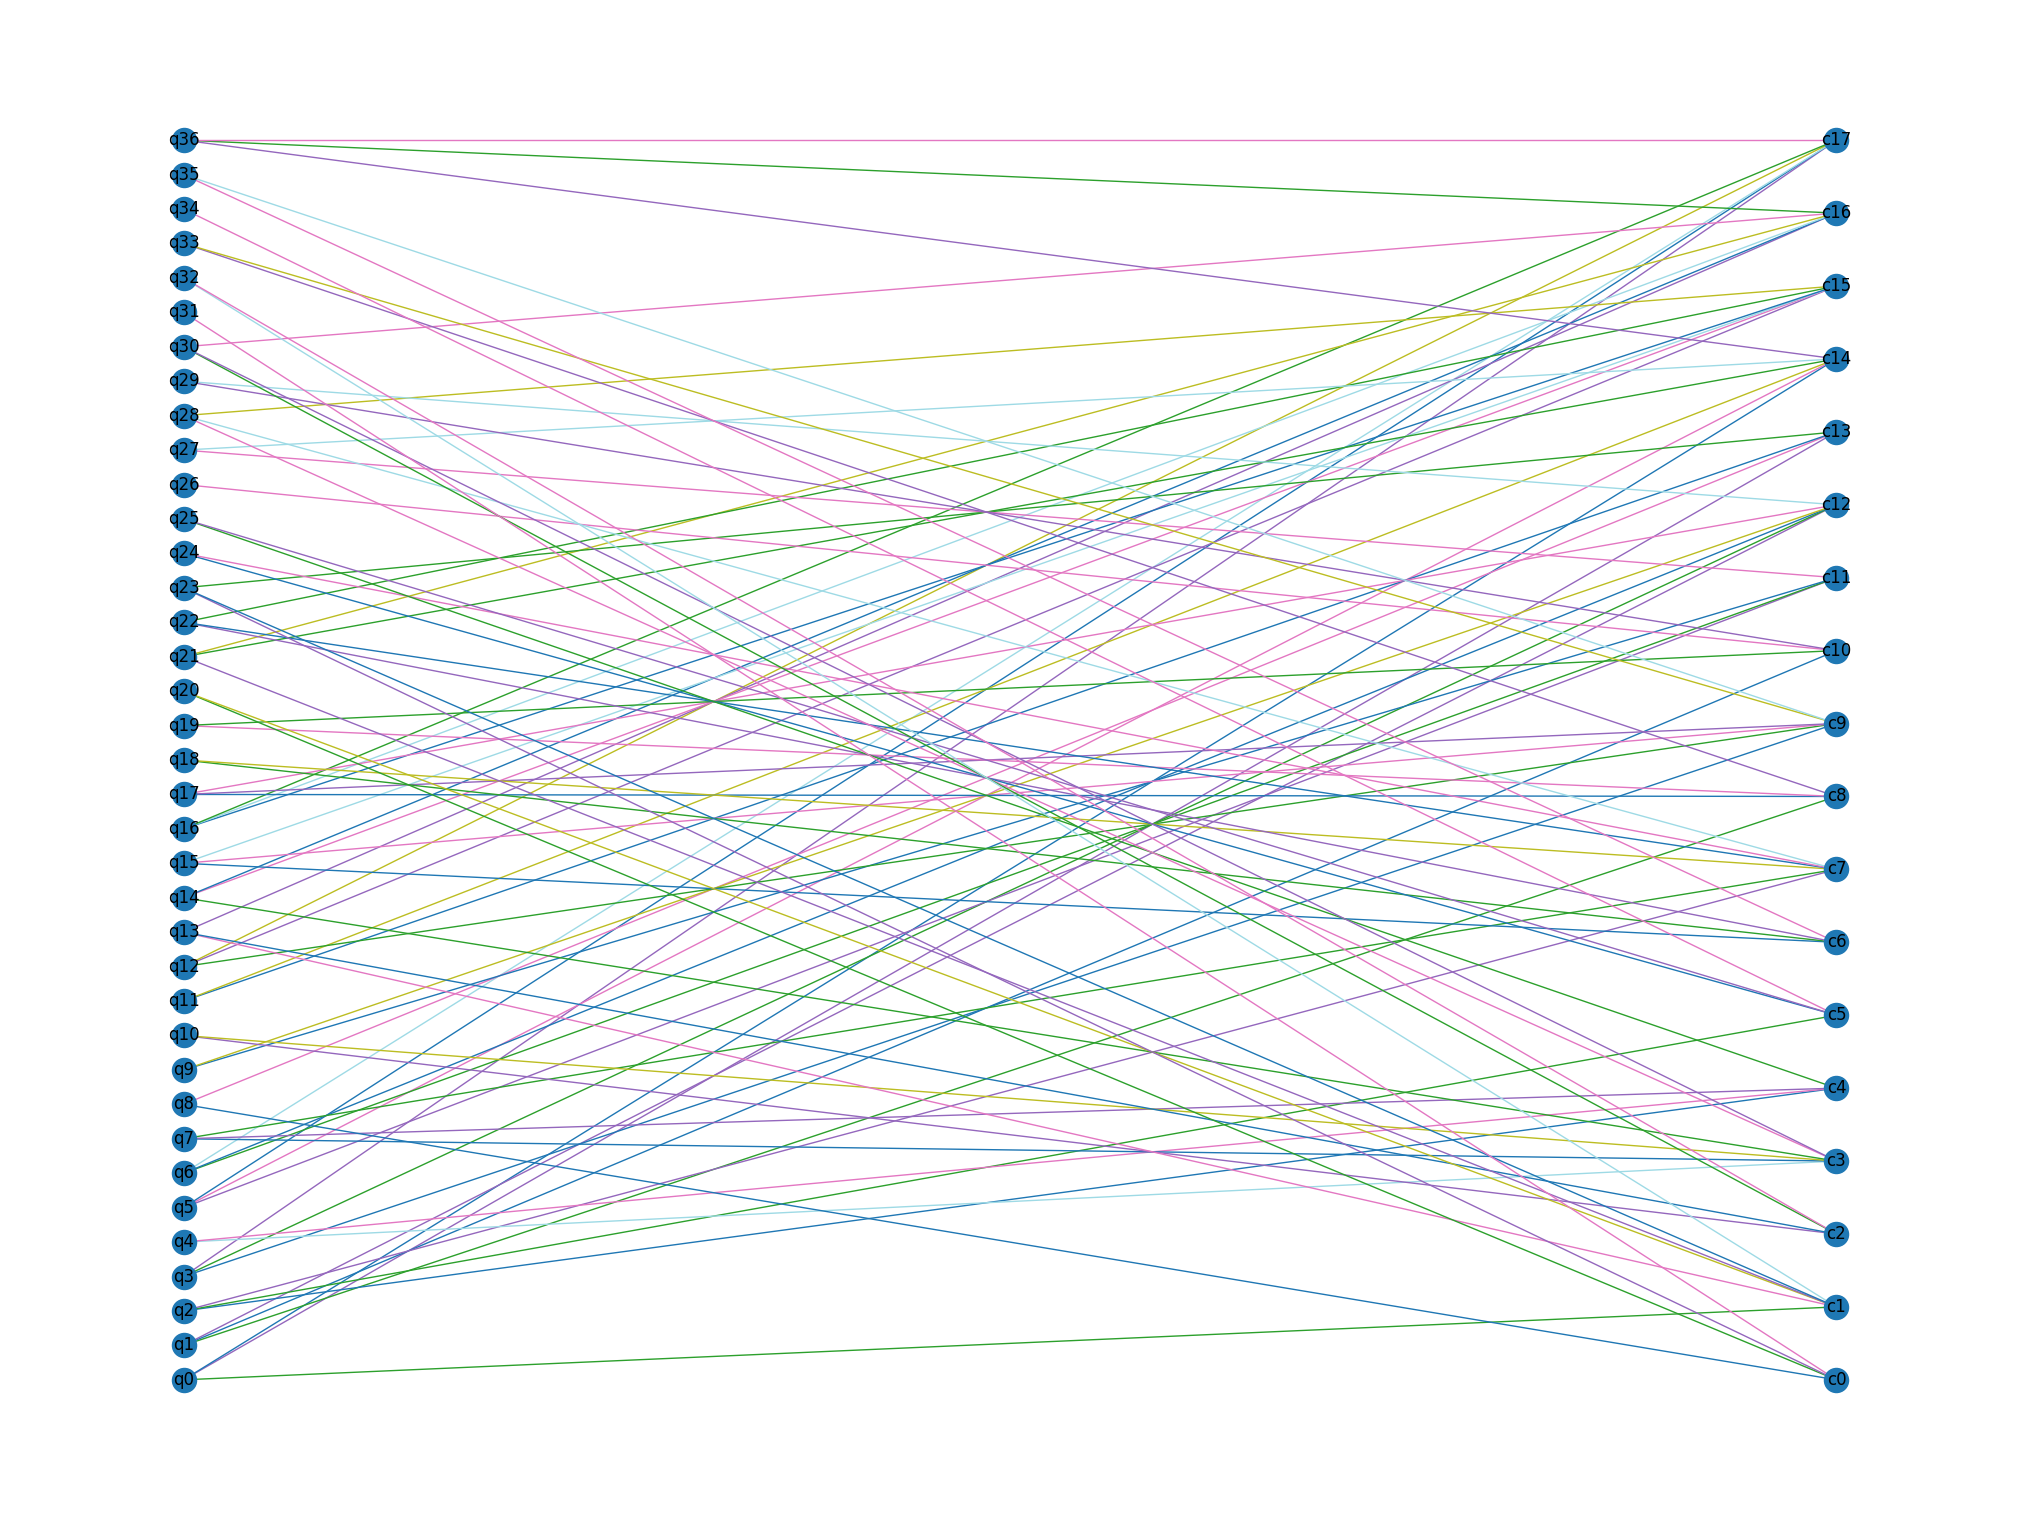

In [10]:
stabs = stabs_z
#find position to integer mapping
#flatten the positions
positions = list(set([item for sublist in stabs for item in sublist]))
mapping = {value: key for key,value in enumerate(positions)}

#find check matrix
def check_matrix(stabs, mapping):
    """create check matrix given some stabilizers and a mapping"""
    cols = len(mapping)
    rows = len(stabs)
    arr = np.zeros((rows, cols), dtype = int)
    for k,stab in enumerate(stabs):
        stab_int = [mapping[pos] for pos in stab]
        for label in stab_int:
            arr[k, label] = 1

    return arr

arr = check_matrix(stabs, mapping)

#create tanner graph
def tanner_graph(arr):
    """given a check matrix, create a tanner graph."""
    rows, cols = arr.shape

    G = nx.Graph()

    # qubit nodes
    G.add_nodes_from([f"q{i}" for i in range(cols)])
    # check nodes
    G.add_nodes_from([f"c{i}" for i in range(rows)])

    for i in range(rows):
        for j in range(cols):
            if arr[i, j] == 1:
                G.add_edge(f"c{i}", f"q{j}")

    return G

G = tanner_graph(arr)

#PLOT
q_nodes = [f"q{i}" for i in range(np.shape(arr)[1])]

# compute layout
pos = nx.bipartite_layout(G, q_nodes)

# draw
#plt.figure(figsize=(20,15))  # width, height in inches
#nx.draw(G, pos, with_labels=True)
#plt.show()

#for node, deg in G.degree():
#    if node.startswith("q"):
#        print(f"{node} (qubit): {deg}")
#    else:
#        print(f"{node} (check): {deg}")


#-----------create coloring of tanner graph-------------

# Step 1: line graph
L = nx.line_graph(G)

# Step 2: color nodes of line graph
edge_coloring = nx.coloring.greedy_color(L, strategy="largest_first")


#display graph
edge_colors = [edge_coloring[edge] for edge in G.edges]

plt.figure(figsize=(20, 15))
nx.draw(G, pos, with_labels=True, edge_color=edge_colors, edge_cmap=plt.cm.tab20)
plt.show()

In [11]:
max(edge_colors)+1

6

## example of single prism

In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se

import mqt.qecc

import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(0,0,0), "ZZ", "middle"),
    #(Position3DHex(1,1,0), "ZZ", "left"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#middle bottom
#pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
#g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

g.view_as_html()


In [3]:
z=0
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

In [4]:
#star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
#print(len(star_ops_x), len(star_ops_z))

/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec/temp-laura/temp_utils.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


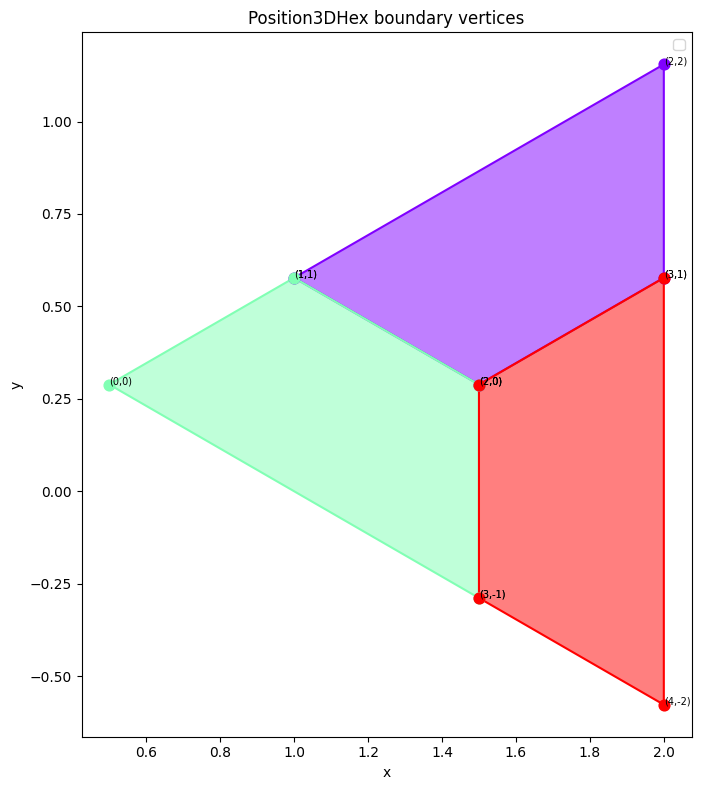

In [5]:
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z)#, star_op=star_ops_z)

In [6]:
#all_paths_stabilizer_product = result.stabilizer_products_x
#assignment = result.assignment#
#all_paths_stars = result.stars_x
#all_paths = result.paths_x
#idx = 0
#for el in all_paths[idx]:
#    print(el)
#temp_utils.plot_position_dict_3color(size = (8,8), color_assignment=assignment, stabilizer_product = all_paths_stabilizer_product[idx], star_operators = all_paths_stars[idx], show_positions = True)

In [7]:

SE = se.SyndromeExtractionStimCC(g, d=d)

rounds = 2
after_clifford_depolarization =0.0
before_round_data_depolarization =0.0
after_reset_flip_probability = 0.0
before_measure_flip_probability = 0.0

circuit = SE.run_all(
    rounds,
    after_clifford_depolarization,
    before_round_data_depolarization,
    after_reset_flip_probability,
    before_measure_flip_probability
)


self.mapping:
{Position3DHex(x=3, y=-1, z=0): 0, Position3DHex(x=1, y=1, z=0): 1, Position3DHex(x=2, y=0, z=0): 2, Position3DHex(x=4, y=-2, z=0): 3, Position3DHex(x=0, y=0, z=0): 4, Position3DHex(x=3, y=1, z=0): 5, Position3DHex(x=2, y=2, z=0): 6}
self.mapping_ancillas
{(Position3DHex(x=1, y=1, z=0), Position3DHex(x=2, y=0, z=0), Position3DHex(x=2, y=2, z=0), Position3DHex(x=3, y=1, z=0)): 7, (Position3DHex(x=0, y=0, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=-1, z=0)): 8, (Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=-1, z=0), Position3DHex(x=3, y=1, z=0), Position3DHex(x=4, y=-2, z=0)): 9}
building circuit for z=0...
initialization Z, ZZPosition3DHex(x=0, y=0, z=0)
len stabs_x 3
len stabs_z 3
No horizontal CS available for d<=5. your circuit will be wrong.
stabilizer_product_x init None
stabilizer_product_x ancillas None
horizontal_cs_x []
stabilizer_product_z init None
stabilizer_product_z ancillas None
horizontal_cs_z []
Z detector 

In [8]:
svg = circuit.diagram("timeline-svg")
with open("circuit.svg", "w") as f:
    f.write(str(svg))

In [8]:

# sample the logical observable directly
sampler = circuit.compile_sampler()
results = sampler.sample(shots=10)
print(results)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=100, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False
print("Observable values:", obs_results)            # should be all same value

[[False  True False False False False False  True False False False False
   True False False  True  True  True False]
 [False  True False False False False False  True False False False False
  False False False False False False False]
 [False  True False False False False False  True False False False False
   True  True False False False  True  True]
 [ True False  True False False False  True False  True False False False
   True False False  True  True  True False]
 [ True  True  True False False False  True  True  True False False False
  False  True  True  True False  True False]
 [ True False False False False False  True False False False False False
   True  True  True False  True False False]
 [False False False False False False False False False False False False
   True False  True  True False False  True]
 [ True False False False False False  True False False False False False
   True  True False False False  True  True]
 [ True  True  True False False False  True  Tru

In [14]:
#----hard coded logical measurement outcomes-------

k = 7
z_l_bits = results[:, -k:]
z_l_raw = np.bitwise_xor.reduce(z_l_bits, axis=1)
print("Z_L raw:", z_l_raw)
print("Deterministic:", np.all(z_l_raw == z_l_raw[0]))


#-----------automatized with in built OBS from stim-------------
#only works with compile detector sampler

num_obs = circuit.num_observables
obs = det_results[:, -num_obs:]

z_l_raw = obs[:, 0]   # first observable

print("num_measurements:", circuit.num_measurements)
print("num_observables:", circuit.num_observables)
print("sample shape:", det_results.shape)

print("Z_L raw:", z_l_raw)
print("Deterministic:", np.all(z_l_raw == z_l_raw[0]))

Z_L raw: [False False False False False False False False False False]
Deterministic: True
num_measurements: 19
num_observables: 1
sample shape: (100, 12)
Z_L raw: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False]
Deterministic: True


## run with sinter

In [11]:
d_lst = [3,5]
circuit_builders = [se.SyndromeExtractionStimCC(g, d=d) for d in d_lst]

op_3 = [#transversal z ,d=3
    Position3DHex(x=0, y=0, z=0),
    Position3DHex(x=1, y=1, z=0),
    Position3DHex(x=2, y=2, z=0),
    Position3DHex(x=2, y=0, z=0),
    Position3DHex(x=3, y=1, z=0),
    Position3DHex(x=3, y=-1, z=0),
    Position3DHex(x=4, y=-2, z=0)
]

#!change this if you use more than just a single prism
z=0
d=5
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)
op_5 = list(set([item for sublist in stabs_x for item in sublist])) 


logical_operators = [
    op_3,
    op_5,
]

p_values = list(np.round(np.geomspace(0.0005, 0.02, 10), 6))

rounds = 5 #!ADAPT THIS TO d

stats = se.run_experiment_sinter(
    circuit_builders,
    logical_operators,
    rounds,
    p_values,
)

Starting 2 workers...
20 tasks left:
  workers   decoder eta shots_left errors_left json_metadata                 
        1 tesseract  3m       9999         100 p=0.0005,rounds=5,code_idx=0  
        1 tesseract   ?      10000         100 p=0.000753,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.001135,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.00171,rounds=5,code_idx=0 
        0 tesseract ?·∞      10000         100 p=0.002576,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.003882,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.005848,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.008811,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.013275,rounds=5,code_idx=0
        0 tesseract ?·∞      10000         100 p=0.02,rounds=5,code_idx=0    
        0 tesseract ?·∞      10000         100 p=0.0005,rounds=5,code_idx=1  
        0 tesseract ?·∞    

In [14]:
import sinter
def plot_experiment_sinter(stats: list[sinter.TaskStats], d_lst: list[int]):
    fig, ax = plt.subplots()

    sinter.plot_error_rate(
        ax=ax,
        stats=stats,
        x_func=lambda stat: stat.json_metadata['p'],
        group_func=lambda stat: f"d={d_lst[stat.json_metadata['code_idx']]}",
    )

    ax.set_xlabel("Physical error rate p")
    ax.set_ylabel("Logical error rate")
    ax.set_title("Logical error rate vs physical error rate")
    ax.loglog()
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.legend(title="Code distance")
    plt.tight_layout()
    plt.show()

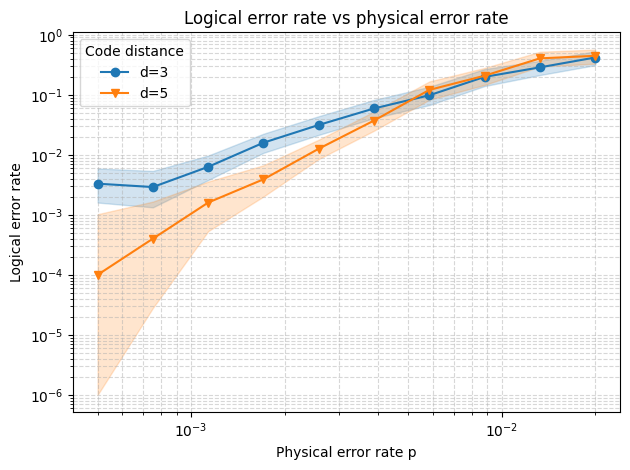

In [15]:
plot_experiment_sinter(stats, d_lst)

## teleportation

In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [36]:
g = PrismGraph("two-patches")

prisms = [
    (Position3DHex(0,0,-1), "ZN", "init"),
    (Position3DHex(0,0,0), "NX", "left"),
    (Position3DHex(1,1,0), "XN", "right"),
    (Position3DHex(1,1,1), "NZ", "final"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)


g.view_as_html()


1 1


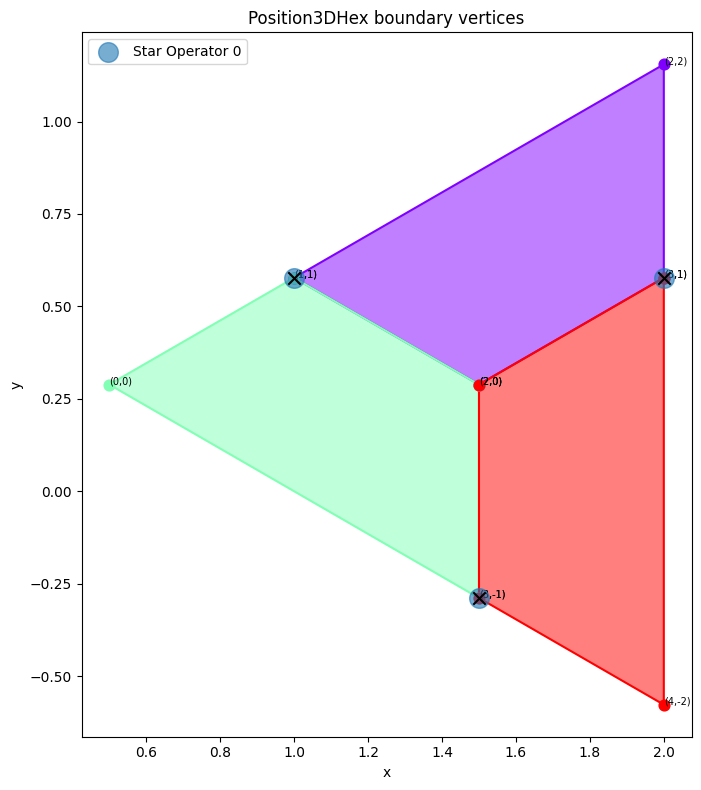

In [37]:
z=-1
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
print(len(star_ops_x), len(star_ops_z))

temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, star_op=star_ops_x)


1 0


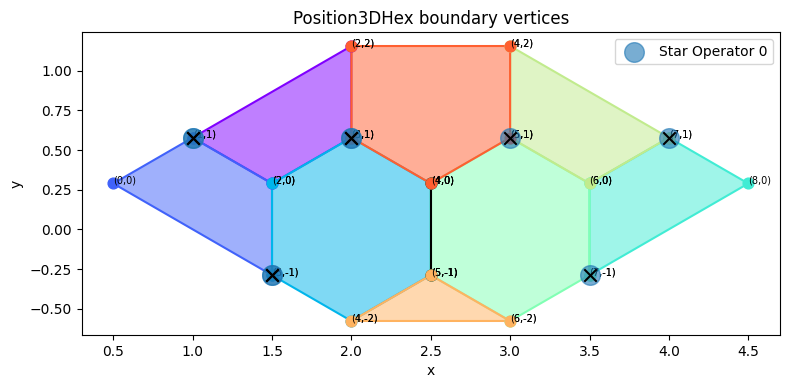

In [38]:
z=0
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
print(len(star_ops_x), len(star_ops_z))

temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, star_op=star_ops_x)


1 1


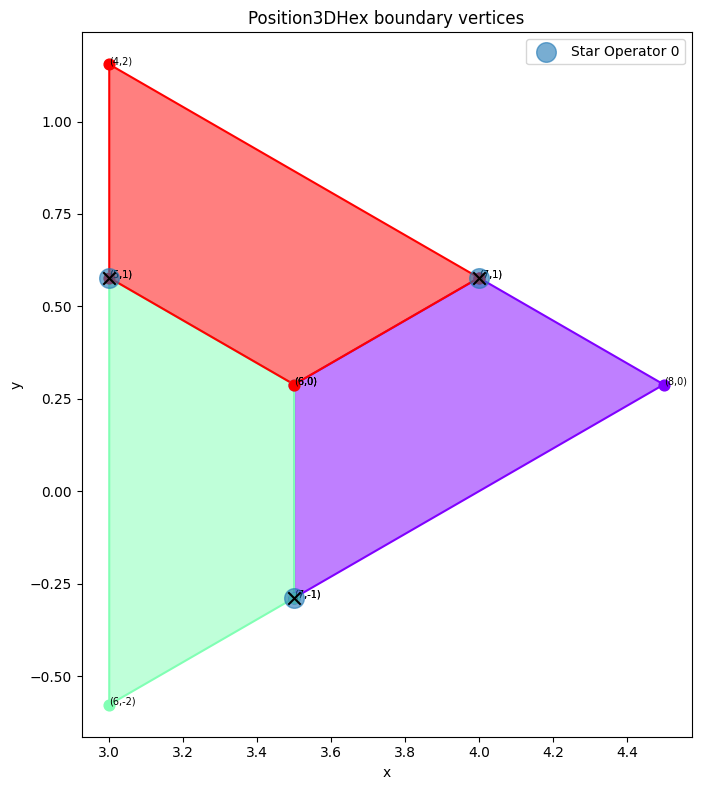

In [39]:
z=1
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
print(len(star_ops_x), len(star_ops_z))

temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, star_op=star_ops_x)


stabilizer tests passed
0 1


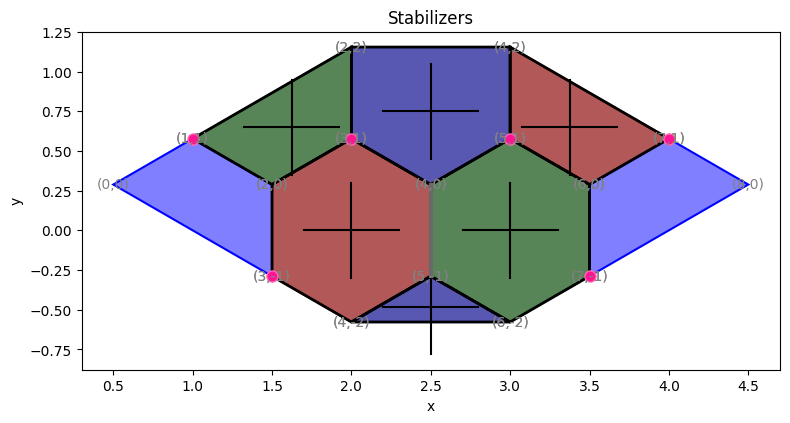

In [40]:
z=0
d=3
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers, = g.stabilizers_timeslice(z,d)

result = g.stabilizer_product_timeslice(z, d, dct_single_type_stabs, dct_patch_stabilizers, testing = True)
print(len(result.stabilizer_products_x), len(result.stabilizer_products_z))

all_paths_stabilizer_product = result.stabilizer_products_z
assignment = result.assignment#
all_paths_stars = result.stars_z
all_paths = result.paths_z
idx = 0
#for el in all_paths[idx]:
#    print(el)
temp_utils.plot_position_dict_3color(size = (8,8), color_assignment=assignment, stabilizer_product = all_paths_stabilizer_product[idx], star_operators = all_paths_stars[idx], show_positions = True)

In [41]:
#SE = se.SyndromeExtractionStimCC(g, d=d)
#SE.retrieve_stabilizers_operators()
#final_prism = SE.prism_graph.prisms[3]
#logical_operator = SE.prism_graph.prism_pipes_to_data_qubits_full[1][final_prism] #prisms from diagram construction

In [42]:
d=3

SE = se.SyndromeExtractionStimCC(g, d=d)
#SE.retrieve_stabilizers_operators()
#final_prism = SE.prism_graph.prisms[3]
#logical_operator = SE.prism_graph.prism_pipes_to_data_qubits_full[1][final_prism] #prisms from diagram construction
#zfinal = 1
#logical_operator = [Position3DHex(x=el.x, y=el.y, z=zfinal) for el in logical_operator]

rounds = 2
after_clifford_depolarization =0.0
before_round_data_depolarization =0.0
after_reset_flip_probability = 0.0
before_measure_flip_probability = 0.0

circuit = SE.run_all(
    rounds,
    after_clifford_depolarization,
    before_round_data_depolarization,
    after_reset_flip_probability,
    before_measure_flip_probability
)


stabilizer tests passed
self.mapping:
{Position3DHex(x=6, y=-2, z=0): 0, Position3DHex(x=6, y=0, z=0): 1, Position3DHex(x=0, y=0, z=0): 2, Position3DHex(x=7, y=1, z=0): 3, Position3DHex(x=2, y=0, z=0): 4, Position3DHex(x=4, y=-2, z=0): 5, Position3DHex(x=2, y=2, z=0): 6, Position3DHex(x=5, y=-1, z=0): 7, Position3DHex(x=8, y=0, z=0): 8, Position3DHex(x=3, y=-1, z=0): 9, Position3DHex(x=1, y=1, z=0): 10, Position3DHex(x=3, y=1, z=0): 11, Position3DHex(x=4, y=0, z=0): 12, Position3DHex(x=4, y=2, z=0): 13, Position3DHex(x=7, y=-1, z=0): 14, Position3DHex(x=5, y=1, z=0): 15}
self.mapping_ancillas
{(Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=-1, z=0), Position3DHex(x=3, y=1, z=0), Position3DHex(x=4, y=-2, z=0), Position3DHex(x=4, y=0, z=0), Position3DHex(x=5, y=-1, z=0)): 16, (Position3DHex(x=4, y=0, z=0), Position3DHex(x=5, y=-1, z=0), Position3DHex(x=5, y=1, z=0), Position3DHex(x=6, y=-2, z=0), Position3DHex(x=6, y=0, z=0), Position3DHex(x=7, y=-1, z=0)): 17, (Position3DHex(x=2, y

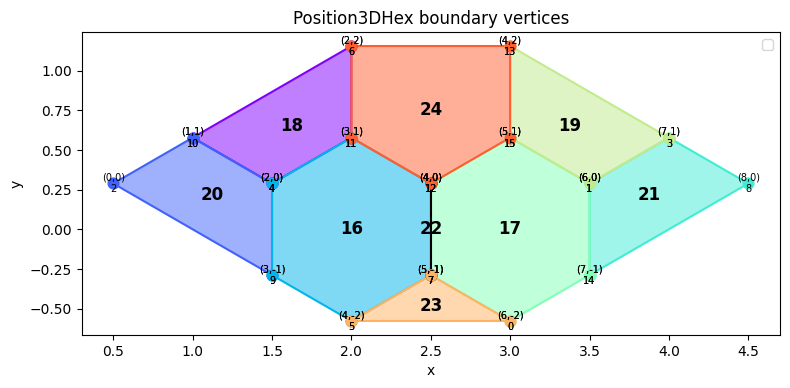

In [43]:
stabs_x, stabs_z = SE.result_dct[0]["stabs"]
mapping = SE.mapping
mapping_ancillas = SE.mapping_ancillas
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_z, mapping=mapping, mapping_ancillas = mapping_ancillas)

In [44]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_d{d}.svg", "w") as f:
    f.write(str(svg))

In [45]:
N=10
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=10, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? False
[[False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False]
 [False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False]
 [False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False]
 [False False False False False False False False False False False False
  False 

In [46]:
num_obs = circuit.num_observables
obs = det_results[:, -num_obs:]

z_l_raw = obs[:, 0]   # first observable

print("num_measurements:", circuit.num_measurements)
print("num_observables:", circuit.num_observables)
print("sample shape:", det_results.shape)

print("Z_L raw:", z_l_raw)
print("Deterministic:", np.all(z_l_raw == z_l_raw[0]))

num_measurements: 76
num_observables: 1
sample shape: (10, 48)
Z_L raw: [False False False False False False False False False False]
Deterministic: True


In [25]:
circuit.detector_error_model()

stim.DetectorErrorModel('''
    detector D0
    detector D1
    detector D2
    detector D3
    detector D4
    detector D5
    detector D6
    detector D7
    detector D8
    detector D9
    detector D10
    detector D11
    detector D12
    detector D13
    detector D14
    detector D15
    detector D16
    detector D17
    detector D18
    detector D19
    detector D20
    detector D21
    detector D22
    detector D23
    detector D24
    detector D25
    detector D26
    detector D27
    detector D28
    detector D29
    detector D30
    detector D31
    detector D32
    detector D33
    detector D34
    detector D35
    detector D36
    detector D37
    detector D38
    detector D39
    detector D40
    detector D41
    detector D42
    detector D43
    detector D44
    detector D45
    detector D46
    detector D47
    detector D48
    detector D49
    detector D50
    detector D51
    detector D52
    detector D53
    detector D54
    detector D55
    detector D56
    detector 

## run with sinter

In [ ]:
d_lst = [3,5,7]
circuit_builders = [se.SyndromeExtractionStimCC(g, d=d) for d in d_lst]

p_values = list(np.round(np.geomspace(0.0005, 0.02, 10), 6))

rounds = 2 #!ADAPT THIS TO d

stats = se.run_experiment_sinter(
    circuit_builders,
    rounds,
    p_values,
)

stabilizer tests passed
self.mapping:
{Position3DHex(x=6, y=-2, z=0): 0, Position3DHex(x=6, y=0, z=0): 1, Position3DHex(x=0, y=0, z=0): 2, Position3DHex(x=7, y=1, z=0): 3, Position3DHex(x=2, y=0, z=0): 4, Position3DHex(x=4, y=-2, z=0): 5, Position3DHex(x=2, y=2, z=0): 6, Position3DHex(x=5, y=-1, z=0): 7, Position3DHex(x=8, y=0, z=0): 8, Position3DHex(x=3, y=-1, z=0): 9, Position3DHex(x=1, y=1, z=0): 10, Position3DHex(x=3, y=1, z=0): 11, Position3DHex(x=4, y=0, z=0): 12, Position3DHex(x=4, y=2, z=0): 13, Position3DHex(x=7, y=-1, z=0): 14, Position3DHex(x=5, y=1, z=0): 15}
self.mapping_ancillas
{(Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=-1, z=0), Position3DHex(x=3, y=1, z=0), Position3DHex(x=4, y=-2, z=0), Position3DHex(x=4, y=0, z=0), Position3DHex(x=5, y=-1, z=0)): 16, (Position3DHex(x=4, y=0, z=0), Position3DHex(x=5, y=-1, z=0), Position3DHex(x=5, y=1, z=0), Position3DHex(x=6, y=-2, z=0), Position3DHex(x=6, y=0, z=0), Position3DHex(x=7, y=-1, z=0)): 17, (Position3DHex(x=2, y

Starting 2 workers...


stabilizer tests passed
self.mapping:
{Position3DHex(x=6, y=-2, z=0): 0, Position3DHex(x=6, y=0, z=0): 1, Position3DHex(x=0, y=0, z=0): 2, Position3DHex(x=7, y=1, z=0): 3, Position3DHex(x=2, y=0, z=0): 4, Position3DHex(x=4, y=-2, z=0): 5, Position3DHex(x=2, y=2, z=0): 6, Position3DHex(x=5, y=-1, z=0): 7, Position3DHex(x=8, y=0, z=0): 8, Position3DHex(x=3, y=-1, z=0): 9, Position3DHex(x=1, y=1, z=0): 10, Position3DHex(x=3, y=1, z=0): 11, Position3DHex(x=4, y=0, z=0): 12, Position3DHex(x=4, y=2, z=0): 13, Position3DHex(x=7, y=-1, z=0): 14, Position3DHex(x=5, y=1, z=0): 15}
self.mapping_ancillas
{(Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=-1, z=0), Position3DHex(x=3, y=1, z=0), Position3DHex(x=4, y=-2, z=0), Position3DHex(x=4, y=0, z=0), Position3DHex(x=5, y=-1, z=0)): 16, (Position3DHex(x=4, y=0, z=0), Position3DHex(x=5, y=-1, z=0), Position3DHex(x=5, y=1, z=0), Position3DHex(x=6, y=-2, z=0), Position3DHex(x=6, y=0, z=0), Position3DHex(x=7, y=-1, z=0)): 17, (Position3DHex(x=2, y

ValueError: Worker failed: traceback=Traceback (most recent call last):
  File "/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec-venv/lib/python3.10/site-packages/sinter/_collection/_collection_worker_state.py", line 28, in _fill_in_task
    dem = circuit.detector_error_model(decompose_errors=True, approximate_disjoint_errors=True)
ValueError: The circuit contains non-deterministic detectors.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['D9', 'D11', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords D9:D11 > output_image.svg

This was discovered while analyzing a Z-basis reset (R) on:
    qubit 11

The collapse anti-commuted with these detectors/observables:
    D9
    D11

The backward-propagating error sensitivity for D9 was:
    X4
    X6
    X10
    X11

The backward-propagating error sensitivity for D11 was:
    X4
    X5
    X9
    X11

Circuit stack trace:
    during TICK layer #1 of 81
    at instruction #1 [which is R 9 4 10 5 6 2 11]

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec-venv/lib/python3.10/site-packages/sinter/_collection/_collection_worker_state.py", line 31, in _fill_in_task
    dem = circuit.detector_error_model(approximate_disjoint_errors=True)
ValueError: The circuit contains non-deterministic detectors.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['D9', 'D11', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords D9:D11 > output_image.svg

This was discovered while analyzing a Z-basis reset (R) on:
    qubit 11

The collapse anti-commuted with these detectors/observables:
    D9
    D11

The backward-propagating error sensitivity for D9 was:
    X4
    X6
    X10
    X11

The backward-propagating error sensitivity for D11 was:
    X4
    X5
    X9
    X11

Circuit stack trace:
    during TICK layer #1 of 81
    at instruction #1 [which is R 9 4 10 5 6 2 11]

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec-venv/lib/python3.10/site-packages/sinter/_collection/_collection_worker_state.py", line 243, in run_message_loop
    num_messages_processed = self.process_messages()
  File "/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec-venv/lib/python3.10/site-packages/sinter/_collection/_collection_worker_state.py", line 175, in process_messages
    self.compute_strong_id(new_task=message_body)
  File "/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec-venv/lib/python3.10/site-packages/sinter/_collection/_collection_worker_state.py", line 133, in compute_strong_id
    strong_id = _fill_in_task(new_task).strong_id()
  File "/mnt/c/Users/Laura/Documents/Codes_and_Repos/tqec_cococo/tqec-venv/lib/python3.10/site-packages/sinter/_collection/_collection_worker_state.py", line 33, in _fill_in_task
    dem = circuit.detector_error_model(approximate_disjoint_errors=True, flatten_loops=True)
ValueError: The circuit contains non-deterministic detectors.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['D9', 'D11', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords D9:D11 > output_image.svg

This was discovered while analyzing a Z-basis reset (R) on:
    qubit 11

The collapse anti-commuted with these detectors/observables:
    D9
    D11

The backward-propagating error sensitivity for D9 was:
    X4
    X6
    X10
    X11

The backward-propagating error sensitivity for D11 was:
    X4
    X5
    X9
    X11

Circuit stack trace:
    during TICK layer #1 of 81
    at instruction #1 [which is R 9 4 10 5 6 2 11]


In [16]:
circuit.diagram('detslice-with-ops-svg', filter_coords=['L0', ])

In [ ]:
import sinter
def plot_experiment_sinter(stats: list[sinter.TaskStats], d_lst: list[int]):
    fig, ax = plt.subplots()

    sinter.plot_error_rate(
        ax=ax,
        stats=stats,
        x_func=lambda stat: stat.json_metadata['p'],
        group_func=lambda stat: f"d={d_lst[stat.json_metadata['code_idx']]}",
    )

    ax.set_xlabel("Physical error rate p")
    ax.set_ylabel("Logical error rate")
    ax.set_title("Logical error rate vs physical error rate")
    ax.loglog()
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.legend(title="Code distance")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_experiment_sinter(stats, d_lst)

## MISC

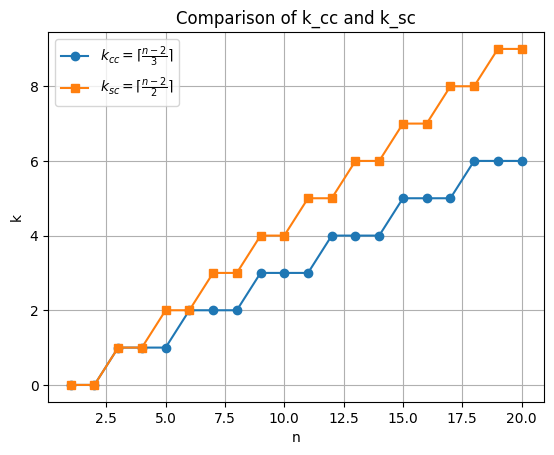

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Define range of n
n_values = np.arange(1, 21)

# Define functions
k_cc = [math.ceil((n - 2) / 3) for n in n_values]
k_sc = [math.ceil((n - 2) / 2) for n in n_values]

# Plot
plt.figure()
plt.plot(n_values, k_cc, marker='o', label=r'$k_{cc} = \lceil \frac{n-2}{3} \rceil$')
plt.plot(n_values, k_sc, marker='s', label=r'$k_{sc} = \lceil \frac{n-2}{2} \rceil$')

# Labels and title
plt.xlabel('n')
plt.ylabel('k')
plt.title('Comparison of k_cc and k_sc')
plt.legend()
plt.grid()

# Show plot
plt.show()

In [32]:
g = PrismGraph("red junction")

prisms = [
    (Position3DHex(0,0,1), "NN", "middle"),
    (Position3DHex(1,1,1), "NN", "middle"),
    (Position3DHex(-1,1,1), "NN", "middle"),

    (Position3DHex(0,0,0), "Port", "1"),
    (Position3DHex(1,1,0), "Port", "2"),
    (Position3DHex(-1,1,0), "Port", "3"),

    (Position3DHex(0,0,2), "Port", "4"),
    (Position3DHex(1,1,2), "Port", "5"),
    (Position3DHex(-1,1,2), "Port", "6"),

    (Position3DHex(2,0,1), "Port", "7"),
    (Position3DHex(-2,0,1), "Port", "8"),

    (Position3DHex(1,-1,1), "Port", "9"),
    (Position3DHex(0,2,1), "Port", "10"),
    (Position3DHex(-2,2,1), "Port", "11")

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

horizontal_pipe = PrismPipeKind(hor=BasisPrism.X, ver=BasisPrism.Z)

# z = 1 (middle layer)
g.add_pipe(prisms[0][0], prisms[1][0], horizontal_pipe)  # (0,0,1) - (1,1,1)
g.add_pipe(prisms[0][0], prisms[2][0], horizontal_pipe)  # (0,0,1) - (-1,1,1)

# outer ports (only neighbors to center)
g.add_pipe(prisms[1][0], prisms[9][0], horizontal_pipe)   # (0,0,0) - (2,0,0)
g.add_pipe(prisms[2][0], prisms[10][0], horizontal_pipe)  # (0,0,0) - (-2,0,0)

#further
g.add_pipe(prisms[0][0], prisms[11][0], horizontal_pipe)
g.add_pipe(prisms[1][0], prisms[12][0], horizontal_pipe)
g.add_pipe(prisms[2][0], prisms[13][0], horizontal_pipe)


vertical_pipe = PrismPipeKind(hor=BasisPrism.N, ver=BasisPrism.N)

# center column
g.add_pipe(prisms[3][0], prisms[0][0], vertical_pipe)
g.add_pipe(prisms[0][0], prisms[6][0], vertical_pipe)

# right column
g.add_pipe(prisms[4][0], prisms[1][0], vertical_pipe)
g.add_pipe(prisms[1][0], prisms[7][0], vertical_pipe)

# left column
g.add_pipe(prisms[5][0], prisms[2][0], vertical_pipe)
g.add_pipe(prisms[2][0], prisms[8][0], vertical_pipe)

g.view_as_html()

(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

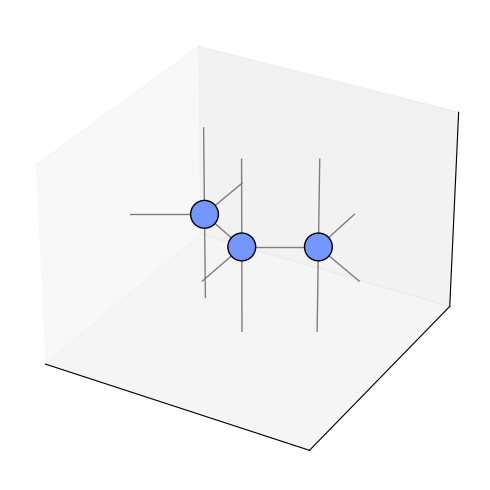

In [33]:
zx = g.to_zx_graph()
zx.draw()